# Multiclass Classifier Showcase

This notebook presents the supervised multiclass wafer-defect classifier built for the project.

It is designed to show:
- the labeled class distribution used for training
- the classifier's training and validation behavior
- held-out test performance and class-wise results
- example predictions on labeled wafers
- confidence behavior when labeling previously unlabeled wafers

Expected pipeline before running this notebook:

```powershell
open experiments/classifier/multiclass/x64/training/notebook.ipynb and run it top to bottom
python scripts/classifier/predict_unlabeled_multiclass.py --config experiments/classifier/multiclass/x64/training/data_config.toml --checkpoint experiments/classifier/multiclass/x64/training/artifacts/multiclass_classifier_50k/best_model.pt
```


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
REPO_ROOT = None
for candidate in candidate_roots:
    if (candidate / "src" / "wafer_defect").exists() and (candidate / "configs").exists():
        REPO_ROOT = candidate
        break

if REPO_ROOT is None:
    raise RuntimeError("Could not locate repo root containing src/wafer_defect and configs/")

SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

NOTEBOOK_DIR = REPO_ROOT / "experiments/classifier/multiclass/x64/showcase"
TRAINING_DIR = NOTEBOOK_DIR.parent / "training"

from wafer_defect.config import load_toml

In [2]:
data_config = load_toml(TRAINING_DIR / "data_config.toml")
train_config = load_toml(TRAINING_DIR / "train_config.toml")

metadata_path = REPO_ROOT / train_config["training"]["metadata_csv"]
artifacts_dir = TRAINING_DIR / "artifacts" / Path(train_config["training"]["output_dir"]).name
history_path = artifacts_dir / "history.csv"
metrics_path = artifacts_dir / "metrics.json"
train_predictions_path = artifacts_dir / "train_predictions.csv"
val_predictions_path = artifacts_dir / "val_predictions.csv"
test_predictions_path = artifacts_dir / "test_predictions.csv"
unlabeled_predictions_path = artifacts_dir / Path(data_config["dataset"]["unlabeled_predictions_csv"]).name

required_paths = [metadata_path, history_path, metrics_path, test_predictions_path]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Missing required classifier artifacts:\n" + "\n".join(str(path) for path in missing_paths)
    )

metadata = pd.read_csv(metadata_path)
history = pd.read_csv(history_path)
metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
train_predictions = pd.read_csv(train_predictions_path) if train_predictions_path.exists() else None
val_predictions = pd.read_csv(val_predictions_path) if val_predictions_path.exists() else None
test_predictions = pd.read_csv(test_predictions_path)
unlabeled_predictions = pd.read_csv(unlabeled_predictions_path) if unlabeled_predictions_path.exists() else None

class_names = (
    metadata[["label_index", "label_name"]]
    .drop_duplicates()
    .sort_values("label_index")["label_name"]
    .tolist()
)

print(f"Metadata: {metadata_path}")
print(f"Artifacts: {artifacts_dir}")
print(f"Classes: {class_names}")

Metadata: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\data\processed\x64\wm811k_multiclass_50k\metadata_labeled_50k.csv
Artifacts: C:\Users\genso\Documents\College_Projects\DeepLearning 2610\Project\experiments\classifier\multiclass\x64\training\artifacts\multiclass_classifier_50k
Classes: ['none', 'Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch']


## Dataset Snapshot

In [3]:
summary = pd.DataFrame(
    {
        "count": metadata["label_name"].value_counts().reindex(class_names),
        "train": metadata[metadata["split"] == "train"]["label_name"].value_counts().reindex(class_names, fill_value=0),
        "val": metadata[metadata["split"] == "val"]["label_name"].value_counts().reindex(class_names, fill_value=0),
        "test": metadata[metadata["split"] == "test"]["label_name"].value_counts().reindex(class_names, fill_value=0),
    }
)
summary

,count,train,val,test
label_name,,,,
none,24481,17137,3672,3672
Center,4294,3006,644,644
Donut,555,389,83,83
Edge-Loc,5189,3632,778,779
Edge-Ring,9680,6776,1452,1452
Loc,3593,2515,539,539
Near-full,149,104,23,22
Random,866,606,130,130
Scratch,1193,835,179,179


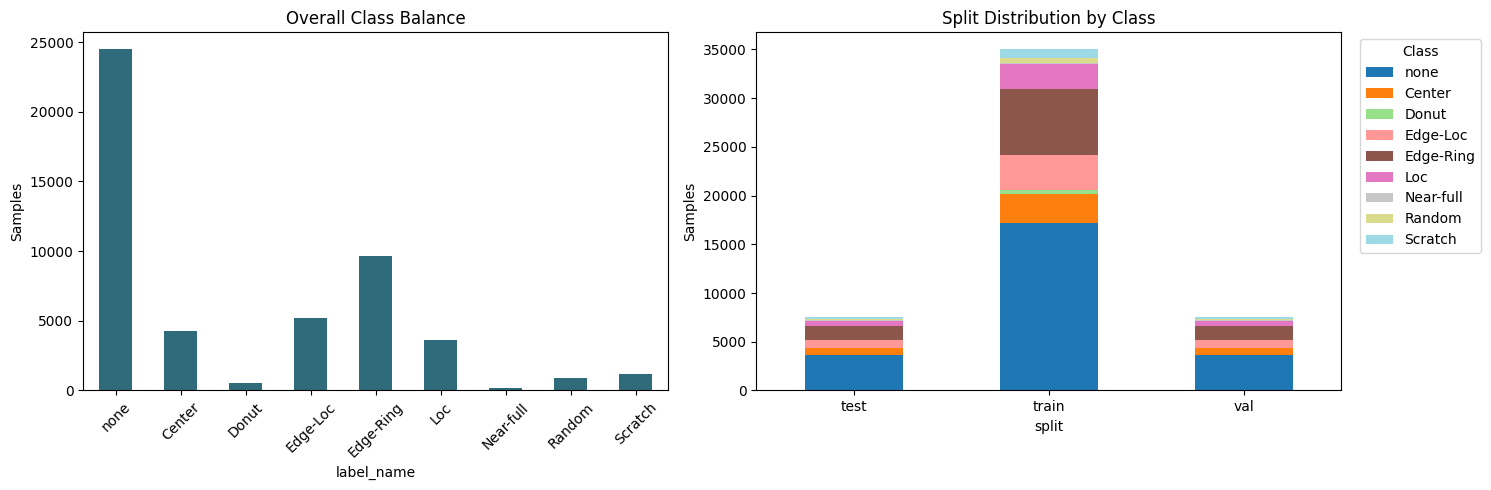

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

summary["count"].plot(kind="bar", ax=axes[0], color="#2F6B7A")
axes[0].set_title("Overall Class Balance")
axes[0].set_ylabel("Samples")
axes[0].tick_params(axis="x", rotation=45)

metadata.groupby(["split", "label_name"]).size().unstack(fill_value=0).reindex(columns=class_names).plot(
    kind="bar", stacked=True, ax=axes[1], colormap="tab20"
)
axes[1].set_title("Split Distribution by Class")
axes[1].set_ylabel("Samples")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## Training Behavior

In [5]:
history.tail()

,epoch,train_loss,train_accuracy,train_balanced_accuracy,train_eval_loss,train_eval_accuracy,train_eval_balanced_accuracy,val_loss,val_accuracy,val_balanced_accuracy,learning_rate
0,1,2.258765,0.101562,0.088865,2.643829,0.054688,0.225,2.80327,0.03125,0.2,0.0005


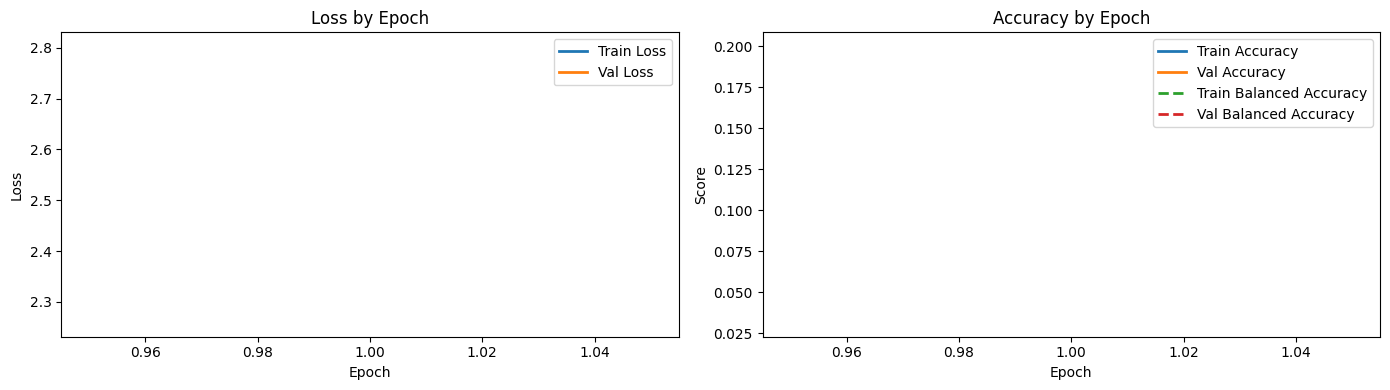

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history["epoch"], history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(history["epoch"], history["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_title("Loss by Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["epoch"], history["train_accuracy"], label="Train Accuracy", linewidth=2)
axes[1].plot(history["epoch"], history["val_accuracy"], label="Val Accuracy", linewidth=2)
axes[1].plot(history["epoch"], history["train_balanced_accuracy"], label="Train Balanced Accuracy", linewidth=2, linestyle="--")
axes[1].plot(history["epoch"], history["val_balanced_accuracy"], label="Val Balanced Accuracy", linewidth=2, linestyle="--")
axes[1].set_title("Accuracy by Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()

plt.tight_layout()
plt.show()

## Held-Out Test Performance

In [7]:
headline_metrics = pd.DataFrame(
    [
        {
            "split": "train",
            "accuracy": metrics["train"]["accuracy"],
            "balanced_accuracy": metrics["train"]["balanced_accuracy"],
        },
        {
            "split": "val",
            "accuracy": metrics["val"]["accuracy"],
            "balanced_accuracy": metrics["val"]["balanced_accuracy"],
        },
        {
            "split": "test",
            "accuracy": metrics["test"]["accuracy"],
            "balanced_accuracy": metrics["test"]["balanced_accuracy"],
        },
    ]
)
headline_metrics

,split,accuracy,balanced_accuracy
0,train,0.042969,0.200000
1,val,0.031250,0.200000
2,test,0.093750,0.257143


In [8]:
test_report = pd.DataFrame(metrics["test"]["classification_report"]).T
class_report = test_report.loc[class_names, ["precision", "recall", "f1-score", "support"]]
class_report.sort_values("f1-score", ascending=False)

,precision,recall,f1-score,support
Loc,0.137931,0.8,0.235294,5.0
Random,0.057143,1.0,0.108108,2.0
none,0.000000,0.0,0.000000,35.0
Center,0.000000,0.0,0.000000,6.0
Donut,0.000000,0.0,0.000000,1.0
Edge-Ring,0.000000,0.0,0.000000,10.0
Edge-Loc,0.000000,0.0,0.000000,5.0
Near-full,0.000000,0.0,0.000000,0.0
Scratch,0.000000,0.0,0.000000,0.0


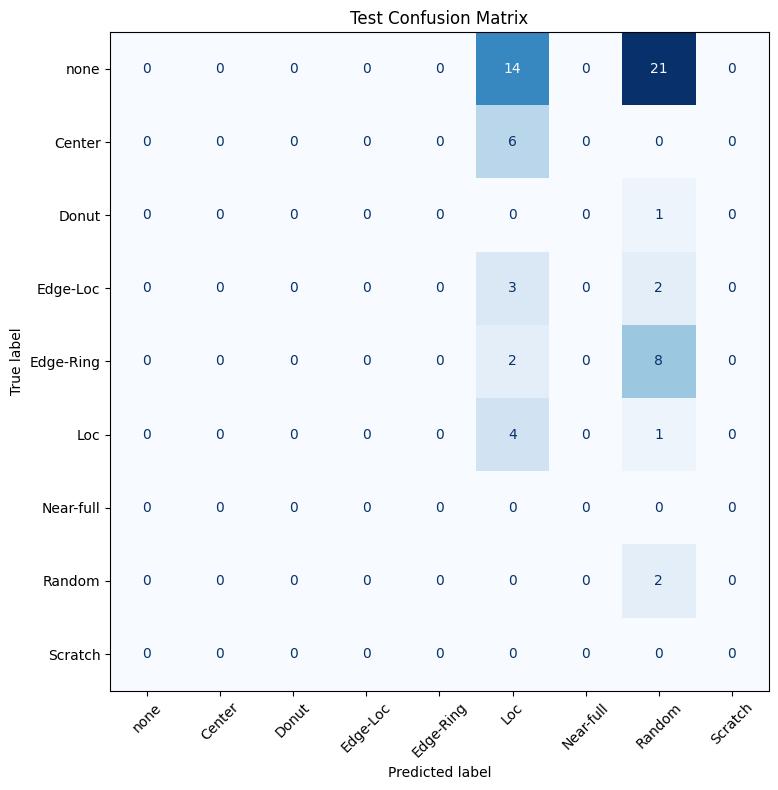

In [9]:
cm = confusion_matrix(
    test_predictions["target_label"],
    test_predictions["predicted_label"],
    labels=class_names,
)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title("Test Confusion Matrix")
plt.tight_layout()
plt.show()

## Example Test Predictions

In [10]:
test_metadata = metadata[metadata["split"] == "test"].reset_index(drop=True).copy()
test_display = test_metadata.join(test_predictions[["predicted_label", "confidence"]])
test_display["correct"] = test_display["label_name"] == test_display["predicted_label"]

correct_examples = test_display[test_display["correct"]].sort_values("confidence", ascending=False).head(6)
error_examples = test_display[~test_display["correct"]].sort_values("confidence", ascending=False).head(6)

print(f"Correct examples shown: {len(correct_examples)}")
print(f"Incorrect examples shown: {len(error_examples)}")

Correct examples shown: 6
Incorrect examples shown: 6


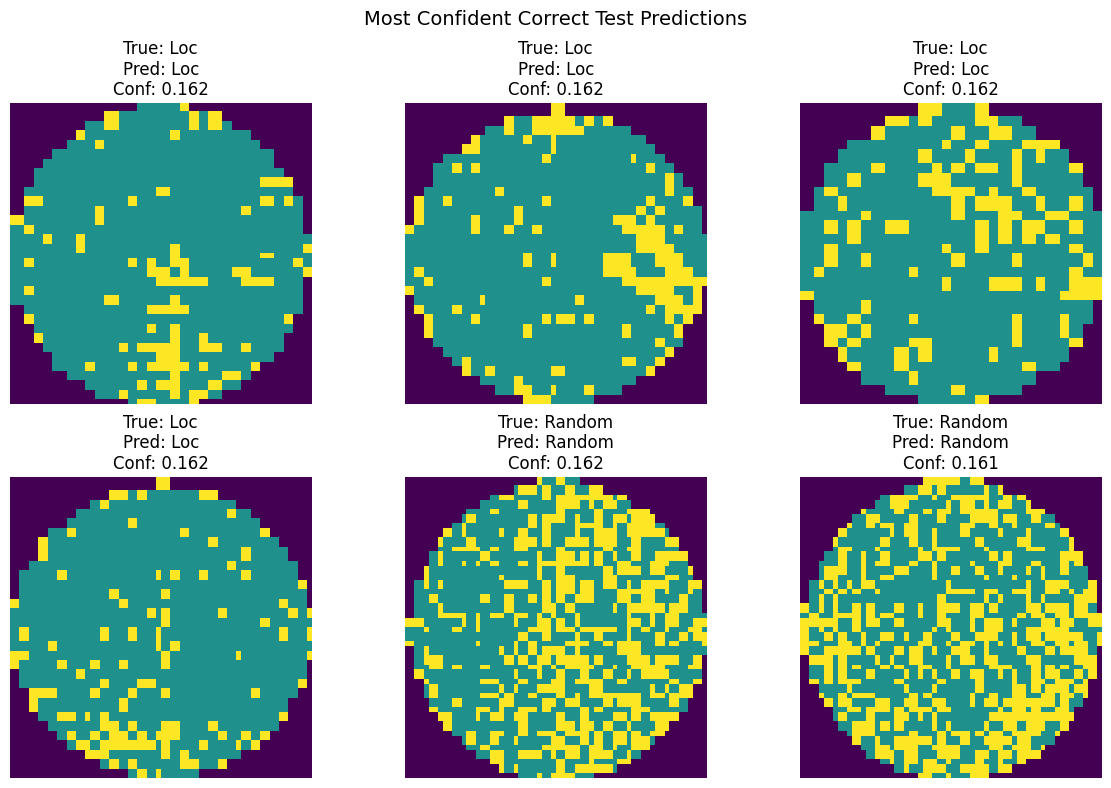

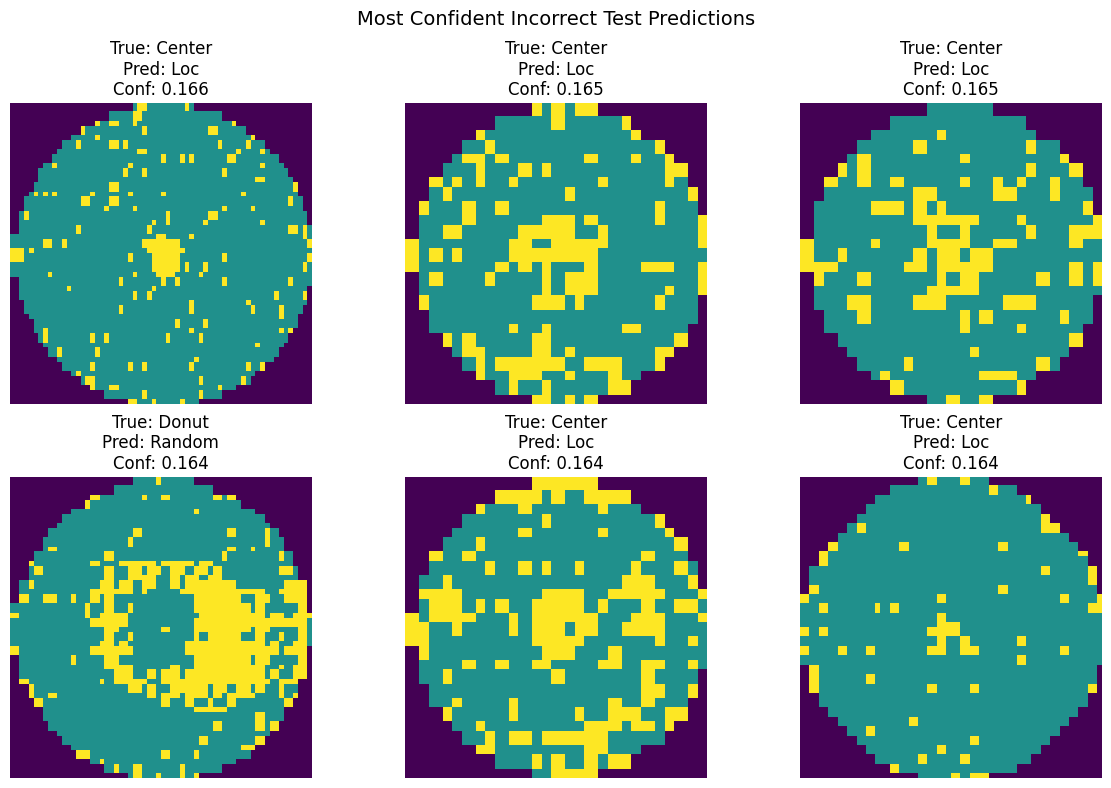

In [11]:
def load_map(array_path: str) -> np.ndarray:
    return np.load(REPO_ROOT / array_path)

def plot_examples(frame: pd.DataFrame, title: str) -> None:
    if frame.empty:
        print(f"No rows available for {title.lower()}.")
        return
    columns = min(3, len(frame))
    rows = int(np.ceil(len(frame) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 4 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, frame.iterrows()):
        ax.imshow(load_map(row["array_path"]), cmap="viridis")
        ax.set_title(
            f"True: {row['label_name']}\nPred: {row['predicted_label']}\nConf: {row['confidence']:.3f}"
        )
        ax.axis("off")
    for ax in axes[len(frame):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_examples(correct_examples, "Most Confident Correct Test Predictions")
plot_examples(error_examples, "Most Confident Incorrect Test Predictions")

## Unlabeled Data Labeling

In [12]:
if unlabeled_predictions is None:
    print("No unlabeled prediction file found yet. Run scripts/classifier/predict_unlabeled_multiclass.py first.")
else:
    print(f"Unlabeled rows labeled: {len(unlabeled_predictions):,}")
    display(unlabeled_predictions.head())

Unlabeled rows labeled: 638,507


,raw_index,predicted_index,predicted_label,confidence,second_choice_label,second_choice_confidence,accepted_for_pseudo_label,pseudo_label_confidence_pct,second_choice_confidence_pct,confidence_margin,predicted_is_defect,checkpoint_name
0,35,3,Edge-Loc,0.892608,none,0.062888,False,89.260834,6.288803,0.829720,True,multiclass_classifier_all_80_10_10_seed07
1,45,5,Loc,0.305202,none,0.264343,False,30.520210,26.434302,0.040859,True,multiclass_classifier_all_80_10_10_seed07
2,69,0,none,0.708615,Loc,0.213615,False,70.861542,21.361522,0.495000,False,multiclass_classifier_all_80_10_10_seed07
3,120,5,Loc,0.822988,none,0.135111,False,82.298768,13.511056,0.687877,True,multiclass_classifier_all_80_10_10_seed07
4,158,0,none,0.942030,Center,0.013214,True,94.202983,1.321391,0.928816,False,multiclass_classifier_all_80_10_10_seed07


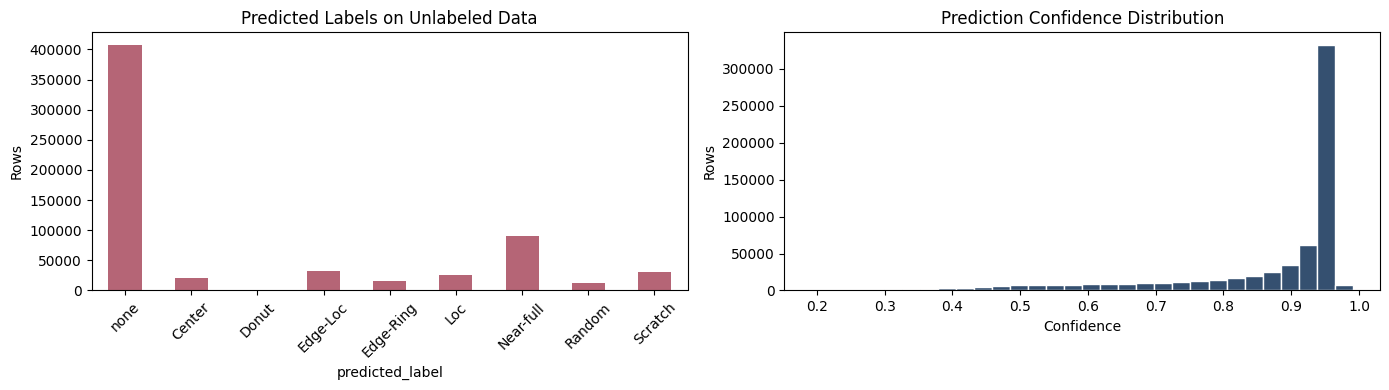

In [13]:
if unlabeled_predictions is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    unlabeled_predictions["predicted_label"].value_counts().reindex(class_names, fill_value=0).plot(
        kind="bar", ax=axes[0], color="#B56576"
    )
    axes[0].set_title("Predicted Labels on Unlabeled Data")
    axes[0].set_ylabel("Rows")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].hist(unlabeled_predictions["confidence"], bins=30, color="#355070", edgecolor="white")
    axes[1].set_title("Prediction Confidence Distribution")
    axes[1].set_xlabel("Confidence")
    axes[1].set_ylabel("Rows")

    plt.tight_layout()
    plt.show()

In [14]:
if unlabeled_predictions is not None:
    uncertain = unlabeled_predictions.sort_values("confidence", ascending=True).head(10)
    confident = unlabeled_predictions.sort_values("confidence", ascending=False).head(10)
    print("Most uncertain unlabeled predictions")
    display(uncertain)
    print("Most confident unlabeled predictions")
    display(confident)

Most uncertain unlabeled predictions


,raw_index,predicted_index,predicted_label,confidence,second_choice_label,second_choice_confidence,accepted_for_pseudo_label,pseudo_label_confidence_pct,second_choice_confidence_pct,confidence_margin,predicted_is_defect,checkpoint_name
594289,621994,3,Edge-Loc,0.191848,Loc,0.187201,False,19.184798,18.720101,0.004647,True,multiclass_classifier_all_80_10_10_seed07
156620,167514,6,Near-full,0.210894,none,0.195561,False,21.089424,19.556117,0.015333,True,multiclass_classifier_all_80_10_10_seed07
221143,235056,3,Edge-Loc,0.215343,Edge-Ring,0.194119,False,21.534282,19.411944,0.021223,True,multiclass_classifier_all_80_10_10_seed07
221097,235010,3,Edge-Loc,0.215343,Edge-Ring,0.194119,False,21.534282,19.411944,0.021223,True,multiclass_classifier_all_80_10_10_seed07
521183,546802,8,Scratch,0.217638,Loc,0.210552,False,21.763778,21.055196,0.007086,True,multiclass_classifier_all_80_10_10_seed07
471098,496397,8,Scratch,0.217638,Loc,0.210552,False,21.763778,21.055196,0.007086,True,multiclass_classifier_all_80_10_10_seed07
171354,182536,6,Near-full,0.218488,none,0.206600,False,21.848837,20.660043,0.011888,True,multiclass_classifier_all_80_10_10_seed07
171368,182550,6,Near-full,0.219573,none,0.215580,False,21.957324,21.558012,0.003993,True,multiclass_classifier_all_80_10_10_seed07
448769,474035,1,Center,0.220118,Loc,0.208293,False,22.011839,20.829315,0.011825,True,multiclass_classifier_all_80_10_10_seed07
554554,580584,8,Scratch,0.221082,Near-full,0.218567,False,22.108167,21.856722,0.002514,True,multiclass_classifier_all_80_10_10_seed07


Most confident unlabeled predictions


,raw_index,predicted_index,predicted_label,confidence,second_choice_label,second_choice_confidence,accepted_for_pseudo_label,pseudo_label_confidence_pct,second_choice_confidence_pct,confidence_margin,predicted_is_defect,checkpoint_name
339392,362608,1,Center,0.991090,Random,0.002297,True,99.108958,0.229659,0.988793,True,multiclass_classifier_all_80_10_10_seed07
320408,342509,7,Random,0.990774,Loc,0.002948,True,99.077362,0.294838,0.987825,True,multiclass_classifier_all_80_10_10_seed07
336101,359030,1,Center,0.990697,Donut,0.002019,True,99.069726,0.201907,0.988678,True,multiclass_classifier_all_80_10_10_seed07
598430,626154,7,Random,0.990429,Loc,0.002820,True,99.042904,0.281963,0.987609,True,multiclass_classifier_all_80_10_10_seed07
3480,10274,7,Random,0.990112,Loc,0.003413,True,99.011189,0.341265,0.986699,True,multiclass_classifier_all_80_10_10_seed07
336340,359285,7,Random,0.989996,none,0.001920,True,98.999584,0.191959,0.988076,True,multiclass_classifier_all_80_10_10_seed07
286056,307416,1,Center,0.989373,none,0.002192,True,98.937279,0.219179,0.987181,True,multiclass_classifier_all_80_10_10_seed07
379964,404470,7,Random,0.989335,Loc,0.003181,True,98.933524,0.318058,0.986155,True,multiclass_classifier_all_80_10_10_seed07
244237,263761,1,Center,0.988810,none,0.002406,True,98.881030,0.240650,0.986404,True,multiclass_classifier_all_80_10_10_seed07
335767,358688,7,Random,0.988714,Loc,0.001930,True,98.871362,0.193002,0.986784,True,multiclass_classifier_all_80_10_10_seed07
